# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [ ]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.13.15 | pandas 2.2.3 | seaborn 0.13.2


In [ ]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/rebrykgeorgi-glitch/ida-practice-3d-KB125/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/rebrykgeorgi-glitch/ida-practice-3d-KB125/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/rebrykgeorgi-glitch/ida-practice-3d-KB125/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [ ]:
def missing_report(frame):
    """Return a DataFrame describing the missing values of `frame`.

    One row per column that has at least one missing value. Columns with
    no missing values are excluded entirely.

    Two columns, in this order:
        'missing'  the count of missing values, an integer
        'percent'  the percentage of rows missing, 0-100, rounded to 2 dp

    Sorted by 'missing', descending. The index is the original column name.
    """
    missing = frame.isna().sum(axis=0).astype(int)
    missing = missing[missing > 0]

    report = pd.DataFrame({
        "missing": missing,
        "percent": (missing / len(frame) * 100).round(2),
    })

    return report.sort_values(by="missing", ascending=False)

In [ ]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [ ]:
def first_and_labelled(frame, sort_column, label):
    """Sort `frame` by `sort_column` descending, then return a tuple:

        (top_row, labelled_row)

    top_row       the row now in FIRST POSITION, as a Series
    labelled_row  the row whose INDEX LABEL equals `label`, as a Series

    Do not reset the index. Both must come from the sorted frame.
    """
    sorted_frame = frame.sort_values(
        by=sort_column,
        ascending=False
    )

    top_row = sorted_frame.iloc[0]
    labelled_row = sorted_frame.loc[label]

    return top_row, labelled_row

In [ ]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Cardeza, Mr. Thomas Drake Martinez | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [ ]:
def fill_age_by_group(frame):
    """Return a COPY of `frame` with missing 'Age' filled by the median age
    of the passenger's (Pclass, Sex) group.

    The argument must not be modified.
    The returned frame must have no missing 'Age'.
    Use groupby(...).transform(...), not a loop, and not agg.
    """
    result = frame.copy()

    group_medians = (
        result.groupby(["Pclass", "Sex"])["Age"]
        .transform("median")
    )

    result["Age"] = result["Age"].fillna(group_medians)

    return result

In [ ]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [ ]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values.

    Index, exactly these four labels in this order:
        'dropna', 'mean', 'median', 'group_median'

    Columns, in this order: 'n', 'mean', 'median', 'std'
        n       number of non-missing values after the strategy is applied
        mean    the mean of the resulting values
        median  the median
        std     the standard deviation (pandas default, ddof=1)

    'group_median' fills with the median of the (Pclass, Sex) group.
    """
    values = frame[column]

    group_medians = (
        frame.groupby(["Pclass", "Sex"])[column]
        .transform("median")
    )

    strategies = {
        "dropna": values.dropna(),
        "mean": values.fillna(values.mean()),
        "median": values.fillna(values.median()),
        "group_median": values.fillna(group_medians),
    }

    rows = []

    for series in strategies.values():
        rows.append({
            "n": int(series.count()),
            "mean": series.mean(),
            "median": series.median(),
            "std": series.std(ddof=1),
        })

    return pd.DataFrame(
        rows,
        index=list(strategies),
        columns=["n", "mean", "median", "std"],
    )

In [ ]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")

                n    mean  median     std
dropna        714 29.6991 28.0000 14.5265
mean          891 29.6991 29.6991 13.0020
median        891 29.3616 28.0000 13.0197
group_median  891 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

Effect of mean imputation:
Std before: 14.5265
Std after:  13.0020
Std decrease: 1.5245
Relative std decrease: 10.49%

Variance before: 211.0191
Variance after:  169.0524
Relative variance decrease: 19.89%


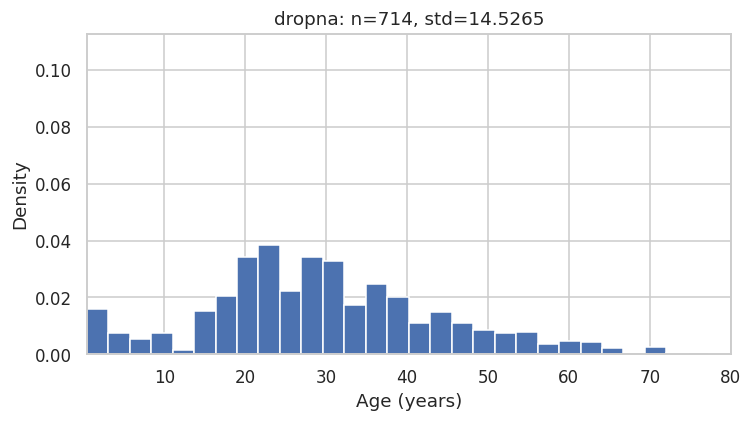

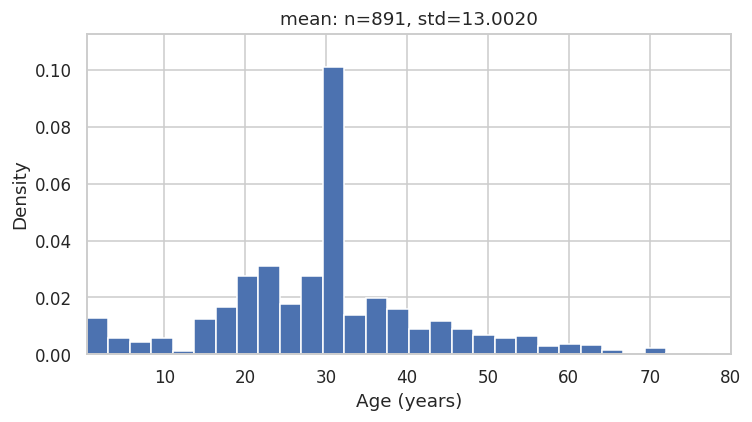

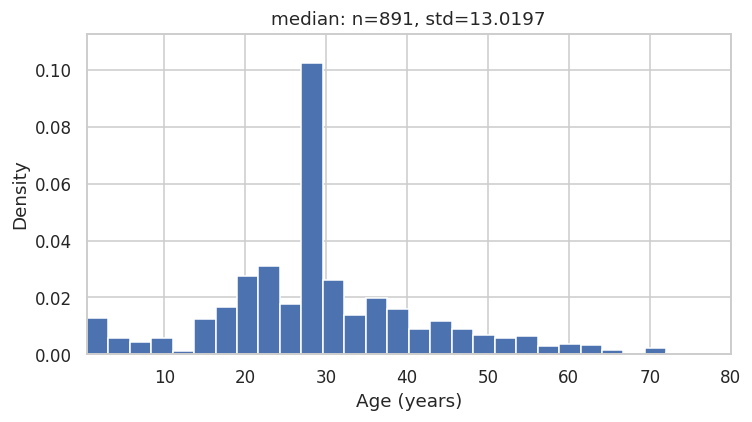

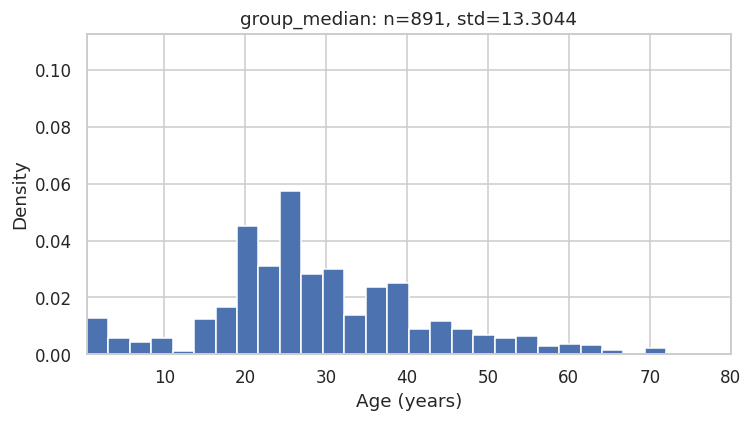


Percentage of missing Age by Pclass:
Pclass
1   13.8900
2    5.9800
3   27.7000
Name: age_missing, dtype: float64

Missing Age by (Pclass, Sex):
                 n  missing  missing_percent
Pclass Sex                                  
1      female   94        9           9.5700
       male    122       21          17.2100
2      female   76        2           2.6300
       male    108        9           8.3300
3      female  144       42          29.1700
       male    347       94          27.0900


In [ ]:
# Work with the ORIGINAL Titanic table, before filling missing ages.
q1_age = titanic["Age"]

q1_group_medians = (
    titanic.groupby(["Pclass", "Sex"])["Age"]
    .transform("median")
)

q1_strategies = {
    "dropna": q1_age.dropna(),
    "mean": q1_age.fillna(q1_age.mean()),
    "median": q1_age.fillna(q1_age.median()),
    "group_median": q1_age.fillna(q1_group_medians),
}

# (a) Quantify the change in standard deviation and variance.
q1_std_before = q1_strategies["dropna"].std(ddof=1)
q1_std_after = q1_strategies["mean"].std(ddof=1)

q1_var_before = q1_strategies["dropna"].var(ddof=1)
q1_var_after = q1_strategies["mean"].var(ddof=1)

print("Effect of mean imputation:")
print(f"Std before: {q1_std_before:.4f}")
print(f"Std after:  {q1_std_after:.4f}")
print(f"Std decrease: {q1_std_before - q1_std_after:.4f}")
print(
    f"Relative std decrease: "
    f"{100 * (1 - q1_std_after / q1_std_before):.2f}%"
)

print(f"\nVariance before: {q1_var_before:.4f}")
print(f"Variance after:  {q1_var_after:.4f}")
print(
    f"Relative variance decrease: "
    f"{100 * (1 - q1_var_after / q1_var_before):.2f}%"
)

# Four histograms with identical bin edges and axis limits.
q1_bins = np.linspace(q1_age.min(), q1_age.max(), 31)

q1_ymax = max(
    np.histogram(values, bins=q1_bins, density=True)[0].max()
    for values in q1_strategies.values()
)

for name, values in q1_strategies.items():
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.hist(values, bins=q1_bins, density=True)
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Density")
    ax.set_title(
        f"{name}: n={values.count()}, "
        f"std={values.std(ddof=1):.4f}"
    )
    ax.set_xlim(q1_bins[0], q1_bins[-1])
    ax.set_ylim(0, q1_ymax * 1.1)

    fig.tight_layout()
    plt.show()

# (b) Examine missingness using observed passenger characteristics.
# assign() creates a new table; the original titanic is not changed.
q1_missingness = titanic.assign(age_missing=q1_age.isna())

print("\nPercentage of missing Age by Pclass:")
print(
    (
        100 * q1_missingness.groupby("Pclass")["age_missing"].mean()
    ).round(2)
)

q1_missing_by_group = (
    q1_missingness.groupby(["Pclass", "Sex"])["age_missing"]
    .agg(["size", "sum", "mean"])
)

q1_missing_by_group.columns = ["n", "missing", "missing_percent"]
q1_missing_by_group["missing_percent"] *= 100

print("\nMissing Age by (Pclass, Sex):")
print(q1_missing_by_group.round(2))

**(a)** Mean imputation preserved the mean at 29.6991, but reduced the standard deviation from 14.5265 to 13.0020. This is a decrease of 1.5245 years, or approximately 10.49%; the corresponding variance decreased by approximately 19.89%. All 177 missing ages were replaced by the same value, so the added observations have zero deviation from the mean and artificially reduce the spread. This also creates a concentration of observations around the imputed value in the histogram rather than restoring the unknown ages. The median changed from 28.0000 to 29.6991, which further demonstrates that preserving the mean does not preserve the distribution.

**(b)** Dropping missing ages leaves 714 observations instead of 891, removing 177 passengers, or approximately 19.87% of the data. The three imputation methods retain all 891 rows, but their filled values are estimates rather than additional observed measurements. For estimating the overall age distribution, deleting incomplete observations is unbiased under MCAR: the probability that an age is missing must be independent of the age itself and of other passenger characteristics. Even under MCAR, deletion reduces the amount of available information and therefore the precision of the estimates.

The summary table alone does not establish whether MCAR is plausible for Titanic's Age, because it does not show which passengers have missing ages. I would provisionally use MAR conditional on Pclass and Sex as the working assumption behind group-wise imputation, but I would need to compare the missing-age percentages across these groups to support this choice. Differences between those percentages would provide evidence against MCAR, but would not prove MAR. MNAR remains possible if missingness still depends on the unobserved age after accounting for the observed passenger characteristics.

**(c)** I would choose group-median imputation by Pclass and Sex because it retains all 891 passengers and uses observed group information instead of assigning the same age to all 177 missing observations. Its standard deviation of 13.3044 is closer to the observed-age value of 14.5265 than the global-mean and global-median results of 13.0020 and 13.0197. However, it still changes the mean to 29.1124 and the median to 26.0000, so I would state the conditional-MAR assumption explicitly and report the comparison with the alternative strategies rather than treat the imputed ages as known measurements.

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [ ]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of `series` outside the 1.5 x IQR fences.

    Q1 and Q3 are the 25th and 75th percentiles; IQR = Q3 - Q1.
    The fences are Q1 - multiplier*IQR and Q3 + multiplier*IQR.
    A value strictly outside either fence is an outlier.

    Missing values are never outliers.

    Return a dict with exactly these five keys:
        'q1', 'q3', 'lower', 'upper'   the four numbers, as floats
        'mask'  a boolean Series aligned to `series`, True where outlying
    """
    q1 = float(series.quantile(0.25))
    q3 = float(series.quantile(0.75))

    iqr = q3 - q1

    lower = float(q1 - multiplier * iqr)
    upper = float(q3 + multiplier * iqr)

    mask = (
        (series < lower) | (series > upper)
    ).fillna(False).astype(bool)

    return {
        "q1": q1,
        "q3": q3,
        "lower": lower,
        "upper": upper,
        "mask": mask,
    }

In [ ]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

Outlier counts:
           Fare  Age
IQR x 1.0   141   63
IQR x 1.5   116   11
IQR x 3.0    53    0
IQR x 5.0    31    0
3 sigma      20    2

Statistics and thresholds:
          n    mean  median  std_ddof0      max  IQR_lower  IQR_upper  sigma_lower  sigma_upper
column                                                                                         
Fare    891 32.2042 14.4542    49.6655 512.3292   -26.7240    65.6344    -116.7924     181.2008
Age     714 29.6991 28.0000    14.5163  80.0000    -6.6875    64.8125     -13.8498      73.2481


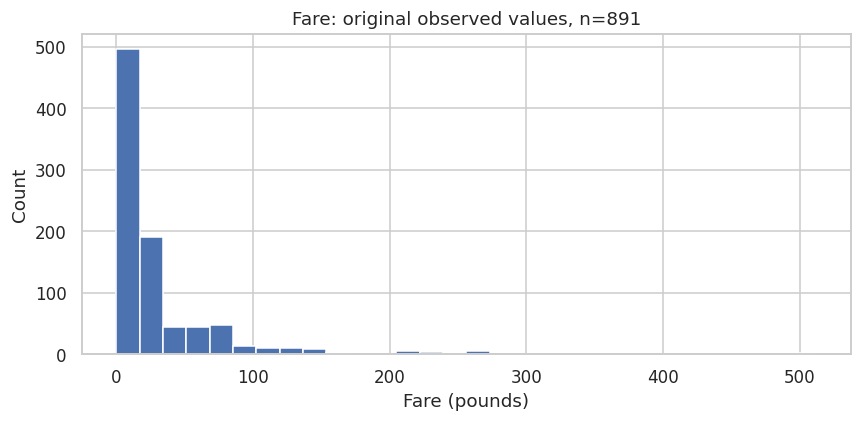

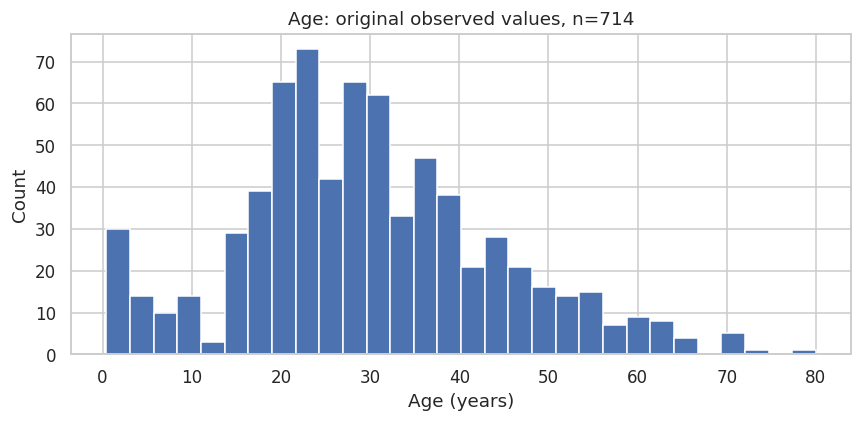


Five highest recorded fares:
 Pclass   Ticket     Fare
      1 PC 17755 512.3292
      1 PC 17755 512.3292
      1 PC 17755 512.3292
      1    19950 263.0000
      1    19950 263.0000


In [ ]:
# Compare four IQR multipliers with the 3-sigma rule.
# Use the original Titanic data, without imputation or outlier removal.

q2_multipliers = [1.0, 1.5, 3.0, 5.0]
q2_rule_names = [
    "IQR x 1.0",
    "IQR x 1.5",
    "IQR x 3.0",
    "IQR x 5.0",
    "3 sigma",
]

q2_counts = {}
q2_details = []

for column in ["Fare", "Age"]:
    # Exclude missing values from the calculations, not extreme values.
    values = titanic[column].dropna()

    # (a), (c): counts for the four IQR multipliers.
    counts = []

    for multiplier in q2_multipliers:
        result = iqr_outliers(values, multiplier=multiplier)
        counts.append(int(result["mask"].sum()))

    # The 3-sigma rule from Lesson 1: population std, ddof=0.
    mean = values.mean()
    sd = values.std(ddof=0)

    sigma_mask = (values - mean).abs() > 3 * sd
    counts.append(int(sigma_mask.sum()))

    q2_counts[column] = counts

    # Details for comparing the default IQR rule with 3 sigma.
    default_iqr = iqr_outliers(values, multiplier=1.5)

    q2_details.append({
        "column": column,
        "n": int(values.count()),
        "mean": mean,
        "median": values.median(),
        "std_ddof0": sd,
        "max": values.max(),
        "IQR_lower": default_iqr["lower"],
        "IQR_upper": default_iqr["upper"],
        "sigma_lower": mean - 3 * sd,
        "sigma_upper": mean + 3 * sd,
    })

q2_counts_table = pd.DataFrame(
    q2_counts,
    index=q2_rule_names,
)

q2_details_table = pd.DataFrame(q2_details).set_index("column")

print("Outlier counts:")
print(q2_counts_table)

print("\nStatistics and thresholds:")
print(q2_details_table.round(4))

# (b), (c): inspect the distribution of each variable.
for column in ["Fare", "Age"]:
    values = titanic[column].dropna()

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.hist(values, bins=30)
    ax.set_xlabel("Fare (pounds)" if column == "Fare" else "Age (years)")
    ax.set_ylabel("Count")
    ax.set_title(f"{column}: original observed values, n={values.count()}")

    fig.tight_layout()
    plt.show()

# (d): inspect expensive fares together with passenger class and ticket.
print("\nFive highest recorded fares:")
print(
    titanic.sort_values("Fare", ascending=False)[
        ["Pclass", "Ticket", "Fare"]
    ].head(5).to_string(index=False)
)

**(a)** I obtained the following numbers of flagged observations using the original data, without imputation or prior outlier removal:

| Rule | Fare: flagged observations | Age: flagged observations |
|---|---:|---:|
| IQR × 1.0 | 141 | 63 |
| IQR × 1.5 | 116 | 11 |
| IQR × 3.0 | 53 | 0 |
| IQR × 5.0 | 31 | 0 |
| 3σ | 20 | 2 |

Increasing the IQR multiplier widens the interval between the lower and upper fences, so fewer observations are flagged. The 3σ calculations use the mean and standard deviation of the observed values, with ddof=0.

**(b)** The rules disagree strongly on Fare because its distribution is right-skewed, with many relatively inexpensive tickets and a long tail of expensive tickets. The mean is 32.2042, compared with a median of 14.4542, while the maximum recorded fare is 512.3292. These large values pull the mean upward and inflate the standard deviation, which is 49.6655.

The standard deviation is particularly sensitive because it is calculated from squared deviations from the mean. Consequently, the upper 3σ threshold moves outward to 181.2008, whereas the upper fence for IQR × 1.5 is only 65.6344. Some extreme fares therefore help widen the very threshold being used to detect them. The IQR rule depends on the middle 50% of the distribution and is less sensitive to the magnitudes of the largest observations, which explains why it flags 116 fares rather than 20.

**(c)** For Age, IQR × 1.5 flags 11 of the 714 observed ages, approximately 1.54%, while the 3σ rule flags 2, approximately 0.28%. The disagreement is smaller in absolute counts and percentage-point terms than for Fare, where the corresponding proportions are approximately 13.02% and 2.24%. However, the rules still do not identify exactly the same number of observations.

The age distribution is less strongly right-skewed and has a less extreme upper tail than Fare. Its mean of 29.6991 is relatively close to its median of 28.0000, and the largest observed age is 80. Thus, its standard deviation is not inflated by an extreme upper tail to the same extent as for Fare. This does not mean that Age is perfectly normally distributed or that the two rules should agree exactly, since they use different definitions of an outlier.

**(d)** I would not remove any flagged Fare observations solely because they exceed a statistical threshold. Fare represents the ticket price, and ticket prices differ between passenger classes; a high first-class fare can be a genuine expensive ticket rather than a recording error. Automatically deleting such observations would disproportionately remove expensive tickets and could distort relationships between fare, passenger class and survival. I would retain the observations, inspect their passenger class and ticket information, and only correct or exclude a value if independent evidence from the source records established that it was erroneous.

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [ ]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.

    Return a dict with exactly these three keys:
        'pearson'     the Pearson coefficient, measuring LINEAR association
        'spearman'    the Spearman coefficient, measuring MONOTONIC association
        'difference'  pearson - spearman

    Use pandas' Series.corr(method=...). Return Python floats.
    """
    a = frame[column_a]
    b = frame[column_b]

    pearson = float(a.corr(b, method="pearson"))
    spearman = float(a.corr(b, method="spearman"))

    return {
        "pearson": pearson,
        "spearman": spearman,
        "difference": pearson - spearman,
    }

In [ ]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

Correlation comparison:
                pearson  spearman  difference
curved           0.8605    0.9653     -0.1048
wine_color_hue  -0.5218   -0.4185     -0.1033


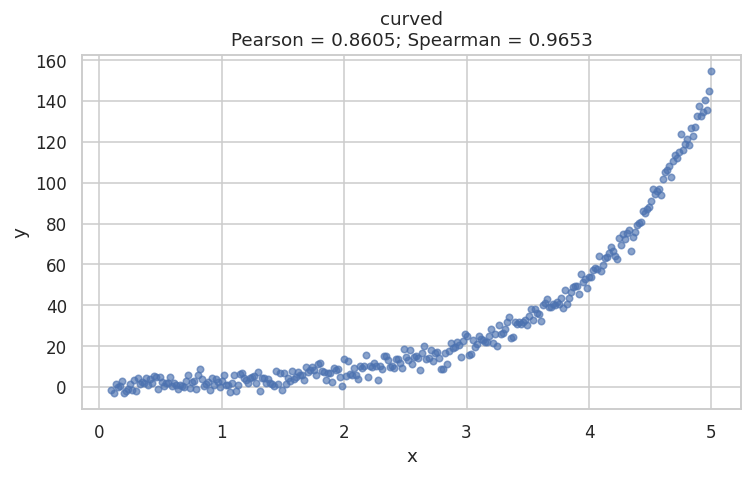

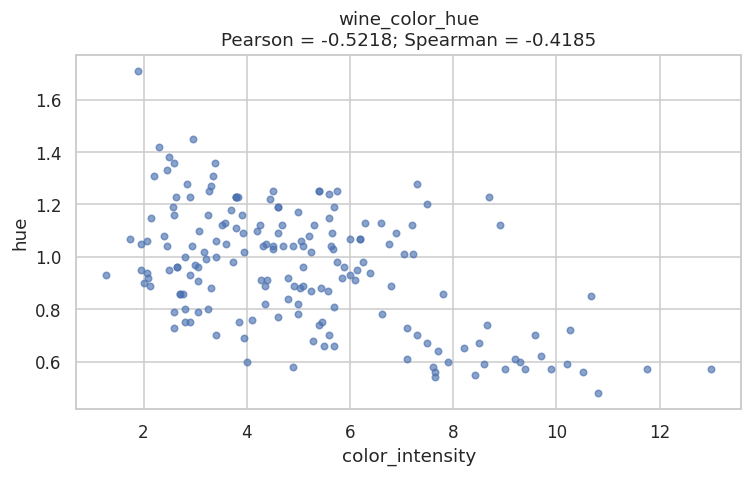

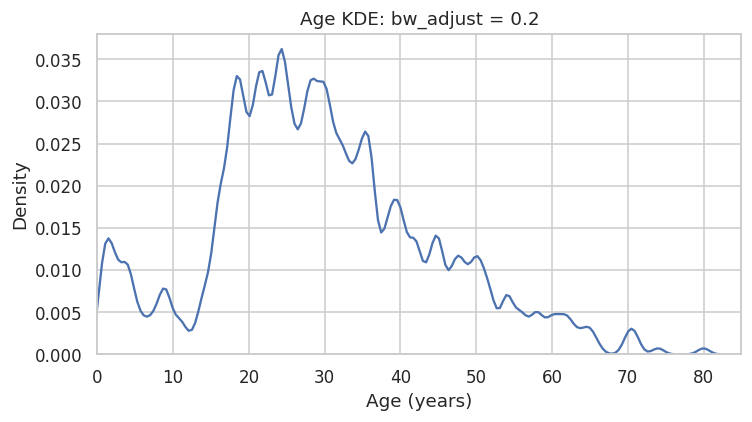

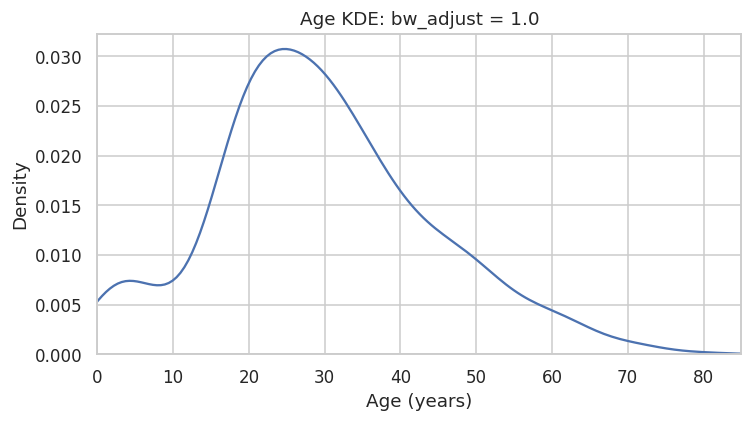

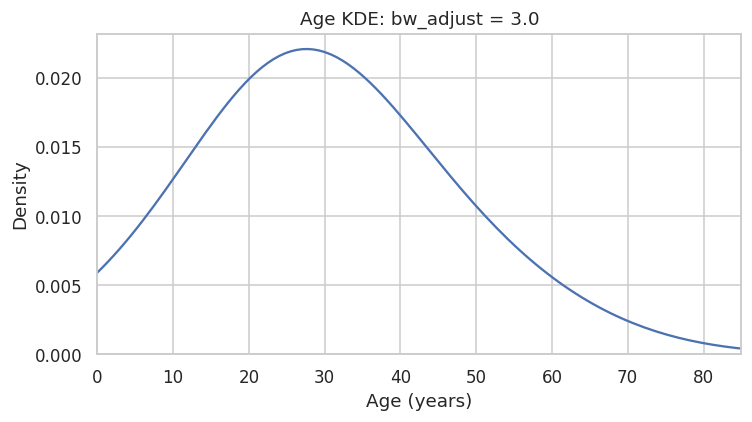

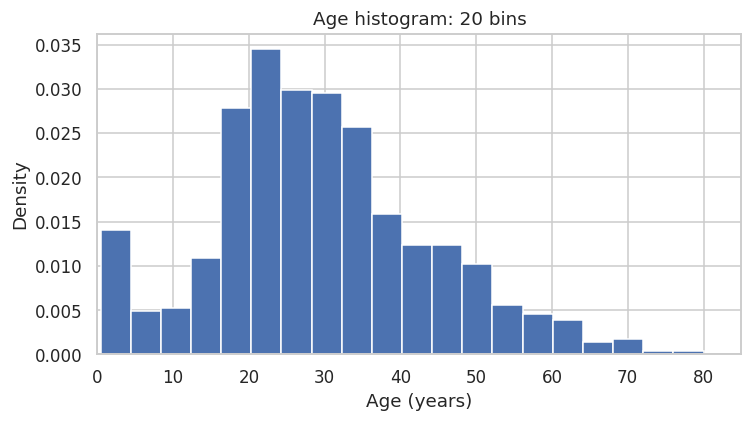

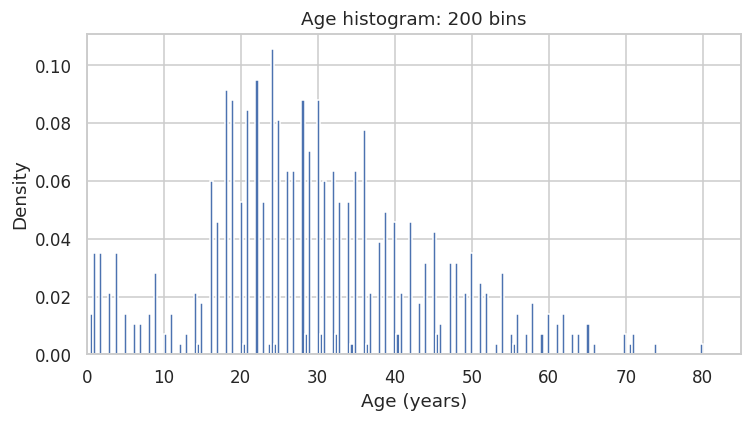


Age recording:
Observed ages: 714
Whole-number ages: 689
Whole-number percentage: 96.50%

Most frequent recorded ages:
Age
24.0000    30
22.0000    27
18.0000    26
28.0000    25
30.0000    25
19.0000    25
21.0000    24
25.0000    23
36.0000    22
29.0000    20


In [ ]:
# (a), (b): compare coefficients and inspect both pairs.
q3_results = pd.DataFrame({
    "curved": correlation_pair(_curved, "x", "y"),
    "wine_color_hue": correlation_pair(
        wine, "color_intensity", "hue"
    ),
}).T

print("Correlation comparison:")
print(q3_results.round(4).to_string())

q3_pairs = [
    ("curved", _curved, "x", "y"),
    ("wine_color_hue", wine, "color_intensity", "hue"),
]

for name, data, column_x, column_y in q3_pairs:
    pearson = q3_results.loc[name, "pearson"]
    spearman = q3_results.loc[name, "spearman"]

    fig, ax = plt.subplots(figsize=(7, 4.5))

    ax.scatter(
        data[column_x],
        data[column_y],
        s=18,
        alpha=0.65,
    )

    ax.set_xlabel(column_x)
    ax.set_ylabel(column_y)
    ax.set_title(
        f"{name}\n"
        f"Pearson = {pearson:.4f}; Spearman = {spearman:.4f}"
    )

    fig.tight_layout()
    plt.show()


# (c): use the original recorded ages, without imputation.
q3_age = titanic["Age"].dropna()

# Use the same horizontal limits for all age plots.
q3_age_limits = (0, float(q3_age.max()) + 5)

# Three KDE plots: change only the bandwidth adjustment.
for bandwidth in [0.2, 1.0, 3.0]:
    fig, ax = plt.subplots(figsize=(7, 4))

    sns.kdeplot(
        x=q3_age,
        bw_adjust=bandwidth,
        ax=ax,
    )

    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Density")
    ax.set_title(f"Age KDE: bw_adjust = {bandwidth}")
    ax.set_xlim(*q3_age_limits)

    fig.tight_layout()
    plt.show()

# Two histograms of exactly the same ages.
for bin_count in [20, 200]:
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.hist(q3_age, bins=bin_count, density=True)

    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Density")
    ax.set_title(f"Age histogram: {bin_count} bins")
    ax.set_xlim(*q3_age_limits)

    fig.tight_layout()
    plt.show()

# Numerical evidence about how ages were recorded.
q3_whole_age = q3_age.mod(1).eq(0)

print("\nAge recording:")
print(f"Observed ages: {q3_age.size}")
print(f"Whole-number ages: {int(q3_whole_age.sum())}")
print(f"Whole-number percentage: {100 * q3_whole_age.mean():.2f}%")

print("\nMost frequent recorded ages:")
print(q3_age.value_counts().head(10).to_string())

**(a)** For the curved pair, I obtained Pearson = 0.8605 and Spearman = 0.9653, with a difference of -0.1048. The scatter plot shows a strong increasing relationship, but it is clearly curved: y increases slowly at smaller x values and much more rapidly at larger x values. Pearson measures linear association between the numerical values, whereas Spearman measures association between their ranks. Consequently, Spearman is closer to 1 because the overall ordering is strongly increasing, even though the observations do not follow a straight line. The added noise causes some changes in that ordering, so the relationship is not perfectly monotonic.

If I were about to fit a linear model to the original variables, I would report Pearson = 0.8605 as the coefficient directly relevant to linear association. However, I would also show the scatter plot and explicitly note the curvature: a high Pearson coefficient does not establish that a straight-line model adequately describes the relationship. Reporting only the higher Spearman coefficient could conceal this limitation.

**(b)** For color_intensity against hue, I obtained Pearson = -0.5218 and Spearman = -0.4185, with a difference of -0.1033. Both coefficients indicate a negative association, but Pearson is stronger in absolute magnitude, unlike in the curved example.

The scatter plot shows considerable overlap and vertical spread at low and moderate color_intensity values, while the observations with high color_intensity tend to have low hue. This is not a clean, consistently decreasing curve across the whole sample. The separation of the high-intensity, low-hue observations from the main cloud contributes strongly to negative covariance because Pearson uses the actual numerical distances from the means. Spearman uses ranks instead, and the ordering within the broad, overlapping central cloud is less consistently decreasing. This pattern helps explain why Pearson is more negative here; the difference does not, by itself, prove that any observations are erroneous.

**(c)** Histogram bin width and KDE bandwidth both control the level of detail used to represent a distribution. Fewer, wider histogram bins and a larger KDE bandwidth smooth the data more strongly, potentially merging peaks and hiding meaningful structure. More, narrower bins and a smaller bandwidth show finer detail, but can make sampling fluctuations and recording artifacts look like distinct population features.

Among the requested settings, bw_adjust = 3.0 gives the strongest KDE smoothing, 1.0 is intermediate, and 0.2 gives the least smoothing. Similarly, a histogram with 20 bins gives a broader summary than one with 200 bins. Narrow peaks in a lightly smoothed KDE or a finely binned histogram should therefore not automatically be interpreted as separate groups of passengers.

The recording statistics provide evidence of an important artifact: 689 of the 714 observed ages, or 96.50%, are whole numbers. For example, age 24 occurs 30 times and age 22 occurs 27 times. The narrow bumps or comb-like structure around frequently recorded whole-number ages at low bandwidth can reflect ages being recorded in whole years rather than distinct peaks in the underlying population's exact ages. This does not mean every peak is artificial; it means the apparent structure must be checked against both the smoothing settings and the way the data were recorded.

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [ ]:
def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.

    `series` holds categorical text with no missing values.

    Build both encodings:
      - label:   the categories sorted alphabetically, mapped to 0, 1, 2, ...
      - one-hot: one binary column per category

    Then, for every unordered pair of DISTINCT categories, compute the
    Euclidean distance between their encodings under each scheme.

    Return a DataFrame with one row per pair, indexed by the string
    "A|B" with A and B in alphabetical order, and two columns:
        'label_distance'    |code(A) - code(B)|
        'onehot_distance'   the Euclidean distance between the two one-hot rows

    Rows sorted by index.
    """
    from itertools import combinations

    categories = sorted(series.unique())

    label_codes = {
        category: code
        for code, category in enumerate(categories)
    }

    category_rows = pd.Series(
        categories, index=categories, dtype="object"
    )
    onehot = pd.get_dummies(category_rows, dtype=int)

    rows = []
    pair_names = []

    for a, b in combinations(categories, 2):
        label_distance = abs(label_codes[a] - label_codes[b])

        difference = (
            onehot.loc[a].to_numpy()
            - onehot.loc[b].to_numpy()
        )
        onehot_distance = float(np.linalg.norm(difference))

        rows.append([label_distance, onehot_distance])
        pair_names.append(f"{a}|{b}")

    return pd.DataFrame(
        rows,
        index=pair_names,
        columns=["label_distance", "onehot_distance"],
    ).sort_index()

In [ ]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

     label_distance  onehot_distance
C|Q               1           1.4142
C|S               2           1.4142
Q|S               1           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

**(a)** Under the original label encoding, the codes are C = 0, Q = 1 and S = 2, so the distances are C–Q = 1, C–S = 2 and Q–S = 1. After changing the category order to Queenstown, Southampton, Cherbourg, the codes become Q = 0, S = 1 and C = 2. The distances then become C–Q = 2, C–S = 1 and Q–S = 1. Therefore, simply changing the category names or their alphabetical order changes the geometry created by label encoding even though the underlying data have not changed. This means a model could consider different ports to be more or less similar purely because of an arbitrary encoding choice. With one-hot encoding, every pair of distinct categories remains the same Euclidean distance, approximately 1.4142, apart.

**(b)** Pclass has a real ordinal relationship: first, second and third class form a meaningful ordered hierarchy, and second class is naturally between first and third. Therefore, representing Pclass as 1, 2 and 3 preserves an ordering that exists in the real meaning of the feature. Embarked is nominal instead: Cherbourg, Queenstown and Southampton are simply different ports, with no meaningful ordering or numerical distance between them. The important distinction is therefore whether the ordering exists in the real-world concept, not how the values are stored.

**(c)** Tree-based models are much less affected by this issue because they split individual features using thresholds rather than relying directly on Euclidean distances between observations. As a result, the numerical distances invented by label encoding matter far less for trees than for distance-based methods such as KNN or k-means.

In [ ]:
# Original label encoding:
# C = 0, Q = 1, S = 2

original_codes = {
    "C": 0,
    "Q": 1,
    "S": 2,
}

# Hypothetical renamed/alphabetical order requested in the question:
# Queenstown, Southampton, Cherbourg
# therefore Q = 0, S = 1, C = 2

renamed_codes = {
    "Q": 0,
    "S": 1,
    "C": 2,
}

pairs = [
    ("C", "Q"),
    ("C", "S"),
    ("Q", "S"),
]

print("Original label encoding:")
for a, b in pairs:
    print(
        f"{a}|{b}: "
        f"{abs(original_codes[a] - original_codes[b])}"
    )

print("\nAfter changing the category order:")
for a, b in pairs:
    print(
        f"{a}|{b}: "
        f"{abs(renamed_codes[a] - renamed_codes[b])}"
    )

print("\nOne-hot distance between any two distinct categories:")
print(np.sqrt(2))

Original label encoding:
C|Q: 1
C|S: 2
Q|S: 1

After changing the category order:
C|Q: 2
C|S: 1
Q|S: 1

One-hot distance between any two distinct categories:
1.4142135623730951


## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [ ]:
def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage.

    Split first with train_test_split, stratifying on y and using the
    given random_state. Then fit a StandardScaler on the TRAINING features
    only, and use it to transform both halves.

    Return a dict with exactly these five keys:
        'X_train', 'X_test'   the scaled feature arrays
        'y_train', 'y_test'   the labels
        'scaler'              the fitted StandardScaler
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler,
    }

In [ ]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# Use the same wine feature matrix and labels as Task 8.
X = wine[_features].values
y = wine["target"].values

# -------------------------------------------------
# (a) StandardScaler vs MinMaxScaler on the same split
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=SEED,
    stratify=y,
)

standard = StandardScaler()
X_train_std = standard.fit_transform(X_train)
X_test_std = standard.transform(X_test)

minmax = MinMaxScaler()
X_train_mm = minmax.fit_transform(X_train)
X_test_mm = minmax.transform(X_test)

print("(a) Test-set ranges:")
print(
    f"StandardScaler: min={X_test_std.min():.4f}, "
    f"max={X_test_std.max():.4f}"
)
print(
    f"MinMaxScaler:   min={X_test_mm.min():.4f}, "
    f"max={X_test_mm.max():.4f}"
)

print(
    "MinMax values outside [0, 1]:",
    int(((X_test_mm < 0) | (X_test_mm > 1)).sum())
)


# -------------------------------------------------
# (b) Add one extreme proline value
# -------------------------------------------------

proline_idx = _features.index("proline")

X_extreme = X.copy()

largest_row = np.argmax(X_extreme[:, proline_idx])
original_max_proline = X_extreme[largest_row, proline_idx]

X_extreme[largest_row, proline_idx] *= 50

# Scale original data
std_original = StandardScaler().fit_transform(X)
mm_original = MinMaxScaler().fit_transform(X)

# Scale data containing the extreme value
std_extreme = StandardScaler().fit_transform(X_extreme)
mm_extreme = MinMaxScaler().fit_transform(X_extreme)

# Compare how the NON-extreme rows of proline moved.
non_extreme = np.ones(len(X), dtype=bool)
non_extreme[largest_row] = False

std_shift = np.mean(
    np.abs(
        std_extreme[non_extreme, proline_idx]
        - std_original[non_extreme, proline_idx]
    )
)

mm_shift = np.mean(
    np.abs(
        mm_extreme[non_extreme, proline_idx]
        - mm_original[non_extreme, proline_idx]
    )
)

print("\n(b) One extreme proline value:")
print(f"Original maximum proline: {original_max_proline:.4f}")
print(
    f"Extreme value used: "
    f"{X_extreme[largest_row, proline_idx]:.4f}"
)

print(
    f"Mean absolute change in NON-extreme proline "
    f"under StandardScaler: {std_shift:.6f}"
)
print(
    f"Mean absolute change in NON-extreme proline "
    f"under MinMaxScaler:   {mm_shift:.6f}"
)

print("\nScaled non-extreme proline range after adding the extreme:")
print(
    "StandardScaler:",
    round(std_extreme[non_extreme, proline_idx].min(), 4),
    "to",
    round(std_extreme[non_extreme, proline_idx].max(), 4),
)
print(
    "MinMaxScaler:",
    round(mm_extreme[non_extreme, proline_idx].min(), 4),
    "to",
    round(mm_extreme[non_extreme, proline_idx].max(), 4),
)


# -------------------------------------------------
# (c) Correct scaling vs leaked scaling
# -------------------------------------------------

correct_scaler = StandardScaler()
correct_scaler.fit(X_train)

leaky_scaler = StandardScaler()
leaky_scaler.fit(X)   # WRONG on purpose: test-set info is included

print("\n(c) First 5 learned means:")
print("Correct, train only:", np.round(correct_scaler.mean_[:5], 4))
print("Leaked, all data:   ", np.round(leaky_scaler.mean_[:5], 4))

print(
    "\nMean absolute difference between scaler means:",
    np.mean(np.abs(correct_scaler.mean_ - leaky_scaler.mean_))
)

(a) Test-set ranges:
StandardScaler: min=-2.5321, max=4.7572
MinMaxScaler:   min=-0.0436, max=1.1358
MinMax values outside [0, 1]: 7

(b) One extreme proline value:
Original maximum proline: 1680.0000
Extreme value used: 84000.0000
Mean absolute change in NON-extreme proline under StandardScaler: 0.758317
Mean absolute change in NON-extreme proline under MinMaxScaler:   0.325148

Scaled non-extreme proline range after adding the extreme:
StandardScaler: -0.1495 to 0.0542
MinMaxScaler: 0.0 to 0.0152

(c) First 5 learned means:
Correct, train only: [13.0089  2.3275  2.369  19.5476 99.7419]
Leaked, all data:    [13.0006  2.3363  2.3665 19.4949 99.7416]

Mean absolute difference between scaler means: 0.48351233705773644


**(a)** Using the same train/test split, the StandardScaler-transformed test set had values ranging from approximately `-2.5321` to `4.7572`. With MinMaxScaler, the transformed test set ranged from approximately `-0.0436` to `1.1358`, and 7 test-set values fell outside the interval `[0, 1]`.

This is correct rather than a bug because MinMaxScaler was fitted only on the training data. It learned the minimum and maximum values of each feature from the training set, so a test observation that is smaller than the training minimum can be transformed to a value below 0, and a test observation larger than the training maximum can be transformed to a value above 1. Forcing all test values into `[0, 1]` would require using information from the test set when fitting the scaler, which would cause data leakage.

**(b)** The largest original proline value was `1680`, and I multiplied it by 50 to obtain an extreme value of `84000`. After adding this single extreme observation, the non-extreme proline values were compressed to approximately `[-0.1495, 0.0542]` under StandardScaler, while under MinMaxScaler they were compressed into only `[0.0000, 0.0152]`.

MinMaxScaler is especially sensitive to this kind of extreme value because its transformation depends directly on the observed minimum and maximum. The new maximum of `84000` expands the range enormously, so almost all ordinary proline values are mapped very close to zero. StandardScaler is also affected because the extreme observation changes both the mean and the standard deviation, but MinMaxScaler shows the more direct range-compression effect: one extreme maximum determines almost the entire `[0, 1]` scale.

The mean absolute numerical change I measured was `0.758317` for StandardScaler and `0.325148` for MinMaxScaler, but those values are expressed in different transformed coordinate systems and should not be compared directly as a common measure of distortion. The more informative comparison is how the ordinary observations are compressed within each scaler's own output range.

**(c)** The correctly fitted StandardScaler learned its parameters only from the training set. For example, its first five means were approximately `[13.0089, 2.3275, 2.3690, 19.5476, 99.7419]`, whereas fitting the scaler on the complete dataset produced approximately `[13.0006, 2.3363, 2.3665, 19.4949, 99.7416]`. The mean absolute difference between the learned feature means was about `0.4835`.

If the leaked preprocessing pipeline produced a higher test accuracy, that extra accuracy would not represent better generalisation to unseen data. It would partly measure the benefit of information from the test-set feature distribution — such as its means and standard deviations — having already influenced the transformation applied during training. The test set would therefore no longer be fully independent of the training procedure, making the reported accuracy optimistically biased.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [ ]:
from sklearn.decomposition import PCA

def components_for_variance(
    X,
    thresholds=(0.5, 0.8, 0.95, 0.99),
    standardise=True
):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.

    If `standardise` is True, fit a StandardScaler on X and transform it
    before running PCA. Otherwise use X as given.

    Fit PCA with all components and random_state=SEED.

    Return a dict with two keys:
        'cumulative'  the cumulative explained variance ratio, a 1-D array
        'needed'      a dict mapping each threshold to the SMALLEST number
                      of components whose cumulative variance is >= it,
                      as an int (1 means the first component alone suffices)
    """
    if standardise:
        X_used = StandardScaler().fit_transform(X)
    else:
        X_used = X

    pca = PCA(random_state=SEED)
    pca.fit(X_used)

    cumulative = np.cumsum(pca.explained_variance_ratio_)

    needed = {
        threshold: int(np.searchsorted(cumulative, threshold) + 1)
        for threshold in thresholds
    }

    return {
        "cumulative": cumulative,
        "needed": needed,
    }

In [ ]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

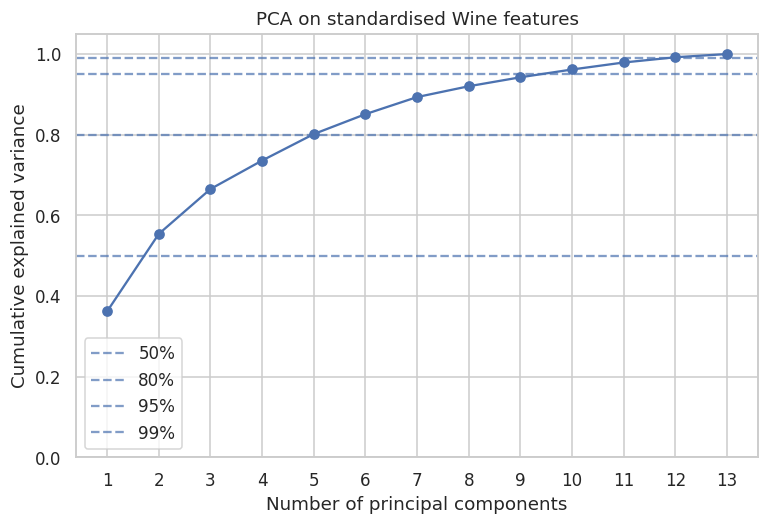

Original feature standard deviations:
proline                        314.9075
magnesium                       14.2825
alcalinity_of_ash                3.3396
color_intensity                  2.3183
malic_acid                       1.1171
flavanoids                       0.9989
alcohol                          0.8118
od280/od315_of_diluted_wines     0.7100
total_phenols                    0.6259
proanthocyanins                  0.5724
ash                              0.2743
hue                              0.2286
nonflavanoid_phenols             0.1245
dtype: float64

Components needed:
50%: 2
80%: 5
95%: 10
99%: 12


In [ ]:
# Cumulative explained variance for the STANDARDISED wine data
cumulative = _scaled_result["cumulative"]

components = np.arange(1, len(cumulative) + 1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    components,
    cumulative,
    marker="o"
)

for threshold in [0.5, 0.8, 0.95, 0.99]:
    ax.axhline(
        threshold,
        linestyle="--",
        alpha=0.7,
        label=f"{threshold:.0%}"
    )

ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA on standardised Wine features")
ax.set_xticks(components)
ax.set_ylim(0, 1.05)
ax.legend()

plt.show()


# Show the original feature scales
print("Original feature standard deviations:")
print(
    wine[_features]
    .std()
    .sort_values(ascending=False)
    .round(4)
)

print("\nComponents needed:")
for threshold, count in _scaled_result["needed"].items():
    print(f"{threshold:.0%}: {count}")

**(a)** Without standardisation, the first principal component explains approximately 99.81% of the total variance, while after standardisation it explains only 36.20%. The unstandardised first component is dominated mainly by `proline`, whose standard deviation is approximately 314.9075, far larger than that of the other wine features. For comparison, the next-largest standard deviation is only about 14.2825 for `magnesium`, while several other features have standard deviations below 1.

PCA finds directions of maximum variance, so when variables are measured in very different units and numerical scales, a large-scale feature can dominate the covariance matrix simply because of its units. Therefore, the result that one component explains more than 99% of the raw variance does not mean that the original 13 measurements truly contain only one meaningful dimension. It mainly means that `proline` contributes overwhelmingly more numerical variance before scaling. Standardisation puts the features on comparable scales before PCA and prevents this unit-driven dominance.

**(b)** For the standardised wine data, I needed 2 principal components to explain at least 50% of the variance, 5 components for 80%, 10 components for 95%, and 12 components for 99%. The cumulative explained-variance curve shows that there is no uniquely correct percentage threshold: increasing the threshold retains more information but also keeps more dimensions.

The number of components should therefore be chosen according to the downstream task rather than by an arbitrary fixed percentage alone. For a two-dimensional visualisation, keeping only 2 components may be appropriate even though they retain only a little more than 50% of the variance, because visual interpretability is the goal. For predictive modelling, I would treat the number of components as a model-selection choice and compare downstream validation or cross-validation performance. For compression or reconstruction, I would choose the smallest number of components that keeps the reconstruction or information loss within an acceptable level.

**(c)** If a model reports that “component 2 is the strongest predictor”, I can say that the model relies strongly on the second principal direction produced by PCA. However, component 2 is not one original wine measurement. It is a weighted linear combination of the original 13 features.

Therefore, I cannot tell a winemaker that one specific original measurement is the strongest predictor based only on that statement. To interpret component 2 in terms of the original chemistry, I would need to inspect its PCA loadings and identify which original features have the largest positive or negative weights. Even then, those loadings describe how the component is constructed and the model result describes predictive association; neither by itself proves that a particular chemical measurement causes the predicted outcome.

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare."""

    # 1. Standardise
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. PCA reduction for t-SNE
    pca_reducer = PCA(
        n_components=n_pca,
        random_state=seed
    )
    reduced = pca_reducer.fit_transform(X_scaled)

    # 3. t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        init="pca"
    )
    tsne_2d = tsne.fit_transform(reduced)

    # Separate 2-D PCA
    pca_2 = PCA(
        n_components=2,
        random_state=seed
    )
    pca_2d = pca_2.fit_transform(X_scaled)

    explained_2d = float(
        pca_2.explained_variance_ratio_.sum()
    )

    return {
        "pca_2d": pca_2d,
        "tsne_2d": tsne_2d,
        "explained_2d": explained_2d,
        "reduced": reduced,
    }

In [ ]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [ ]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

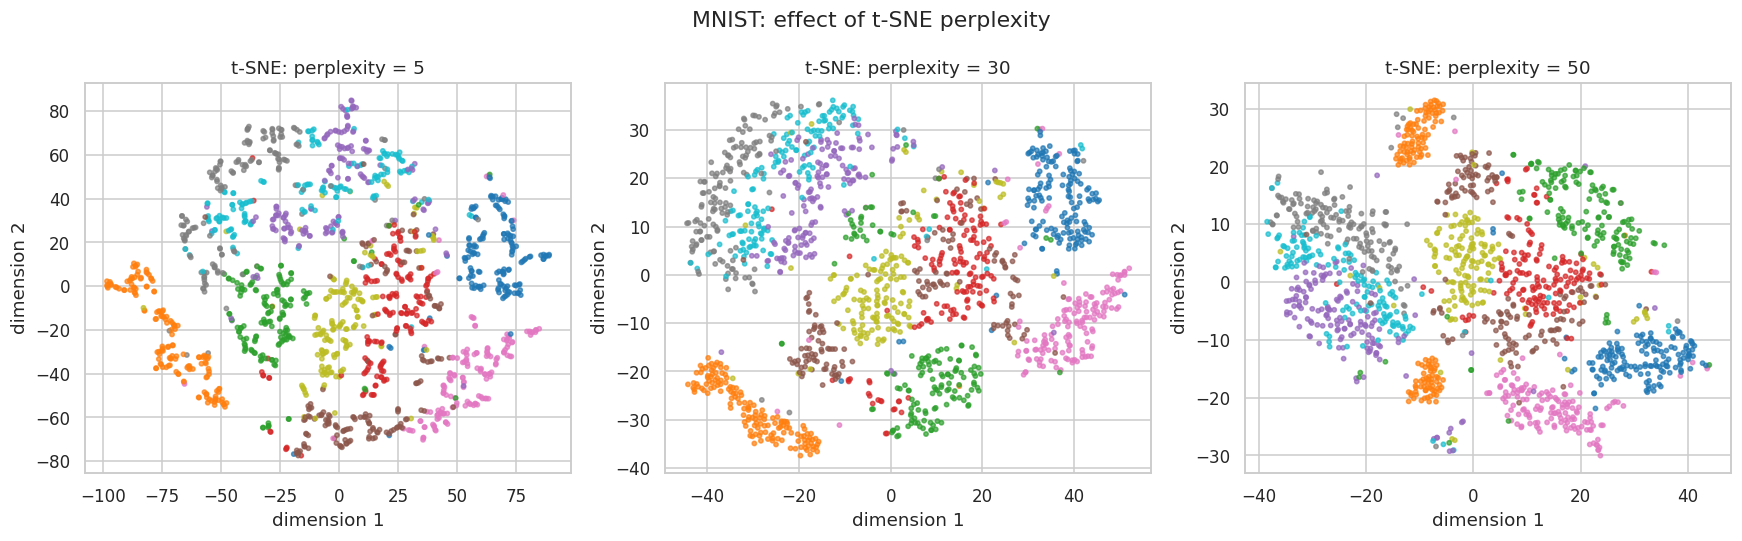

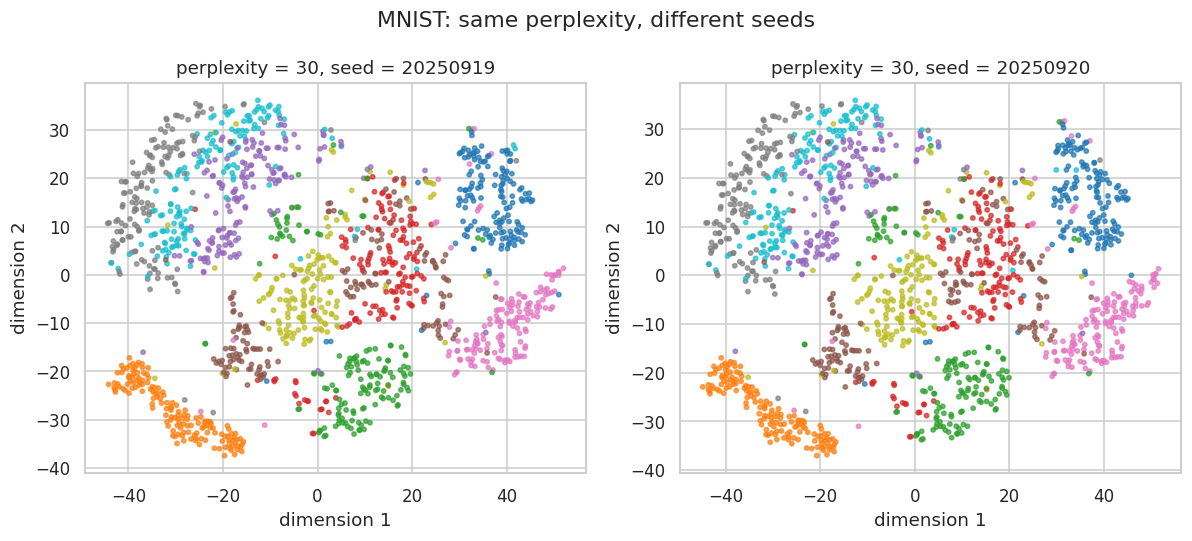

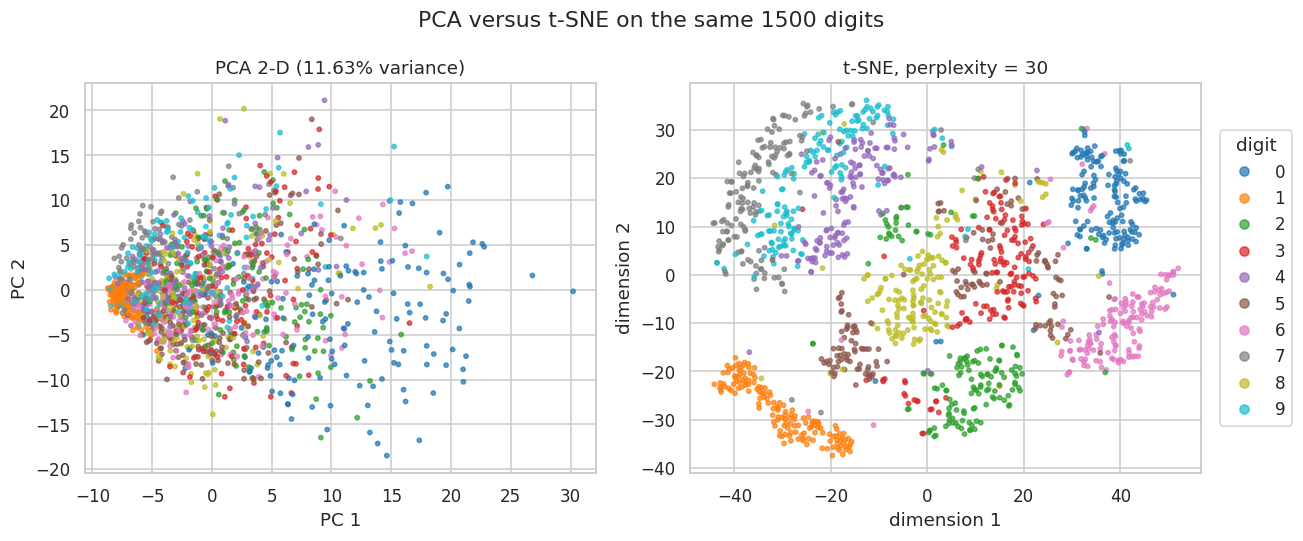

In [ ]:
# Use the FULL 1500-row MNIST sample.
X_full = pixels
y_full = digit_labels

# Standardise once.
X_full_scaled = StandardScaler().fit_transform(X_full)

# Reduce to 50 dimensions before t-SNE.
pca50 = PCA(n_components=50, random_state=SEED)
X_full_reduced = pca50.fit_transform(X_full_scaled)

# -------------------------------------------------
# (a) Same seed, different perplexities
# -------------------------------------------------

perplexities = [5, 30, 50]
perplexity_projections = {}

for p in perplexities:
    tsne = TSNE(
        n_components=2,
        perplexity=p,
        random_state=SEED,
        init="pca"
    )

    perplexity_projections[p] = tsne.fit_transform(X_full_reduced)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, p in zip(axes, perplexities):
    projection = perplexity_projections[p]

    scatter = ax.scatter(
        projection[:, 0],
        projection[:, 1],
        c=y_full,
        cmap="tab10",
        s=8,
        alpha=0.7
    )

    ax.set_title(f"t-SNE: perplexity = {p}")
    ax.set_xlabel("dimension 1")
    ax.set_ylabel("dimension 2")

fig.suptitle("MNIST: effect of t-SNE perplexity")
fig.tight_layout()
plt.show()


# -------------------------------------------------
# (b) Same perplexity, different seeds
# -------------------------------------------------

seeds = [SEED, SEED + 1]
seed_projections = {}

for seed in seeds:
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=seed,
        init="pca"
    )

    seed_projections[seed] = tsne.fit_transform(X_full_reduced)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, seed in zip(axes, seeds):
    projection = seed_projections[seed]

    scatter = ax.scatter(
        projection[:, 0],
        projection[:, 1],
        c=y_full,
        cmap="tab10",
        s=8,
        alpha=0.7
    )

    ax.set_title(f"perplexity = 30, seed = {seed}")
    ax.set_xlabel("dimension 1")
    ax.set_ylabel("dimension 2")

fig.suptitle("MNIST: same perplexity, different seeds")
fig.tight_layout()
plt.show()


# -------------------------------------------------
# (c) PCA 2-D versus t-SNE
# -------------------------------------------------

pca2 = PCA(n_components=2, random_state=SEED)
pca_2d_full = pca2.fit_transform(X_full_scaled)

tsne_30 = perplexity_projections[30]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    pca_2d_full[:, 0],
    pca_2d_full[:, 1],
    c=y_full,
    cmap="tab10",
    s=8,
    alpha=0.7
)

axes[0].set_title(
    f"PCA 2-D ({pca2.explained_variance_ratio_.sum():.2%} variance)"
)
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")

scatter = axes[1].scatter(
    tsne_30[:, 0],
    tsne_30[:, 1],
    c=y_full,
    cmap="tab10",
    s=8,
    alpha=0.7
)

axes[1].set_title("t-SNE, perplexity = 30")
axes[1].set_xlabel("dimension 1")
axes[1].set_ylabel("dimension 2")

axes[1].legend(
    *scatter.legend_elements(),
    title="digit",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

fig.suptitle("PCA versus t-SNE on the same 1500 digits")
fig.tight_layout()
plt.show()

**(a)** Changing the perplexity changes the balance between very local and somewhat broader neighbourhood structure. Roughly, perplexity controls how many neighbours each point is trying to keep close in the low-dimensional embedding.

At perplexity = 5, the classes are more fragmented into small local pieces. Several digit classes break into separated subgroups because each point is trying to preserve a very small neighbourhood. At perplexity = 30, the embedding gives a more balanced picture: many digit classes form recognisable groups while some overlap remains. At perplexity = 50, the groups become broader and more compact, and some neighbouring classes are pulled into larger shared regions. Thus, the low-perplexity extreme tends to shatter classes into local fragments, whereas the higher-perplexity setting tends to merge local structures into larger groups.

None of these pictures is uniquely “correct”. Perplexity changes the scale of neighbourhood structure that t-SNE emphasises.

**(b)** t-SNE is seed-dependent because its low-dimensional embedding is produced by a nonlinear optimisation rather than by a single closed-form projection. Different initial conditions or other stochastic parts of the procedure can lead the optimisation to different layouts that still preserve similar local neighbourhoods.

In my two runs at perplexity = 30, with seeds 20250919 and 20250920, the resulting plots are visually almost identical, so the effect of the seed is small in this particular experiment. However, that does not make the seed irrelevant in general: another dataset or configuration can produce more noticeable differences. A published t-SNE figure should therefore state the random_state and ideally demonstrate that the qualitative conclusions are stable across reasonable seeds. Otherwise, a reader cannot know whether visible structures are robust or partly an artefact of one particular optimisation run.

**(c)** The two-dimensional PCA projection retains only about 11.63% of the total variance in the full 1500-row MNIST sample, and the digit classes overlap heavily. The t-SNE projection at perplexity = 30 separates many digit classes much more clearly because it is designed to preserve local neighbourhoods rather than maximise globally explained variance.

However, the clearer t-SNE picture does not justify several common conclusions.

1. I cannot interpret the t-SNE axes as meaningful features or directions. Unlike PCA components, “dimension 1” and “dimension 2” have no physical or statistical interpretation.
2. I cannot interpret the distance between separate t-SNE clusters as a reliable measure of how different the digit classes are in the original 784-dimensional space. t-SNE deliberately sacrifices global geometry to preserve local neighbourhoods.
3. I cannot interpret the apparent size, area or density of a t-SNE cluster as the true variability or population size of that class, because t-SNE can expand dense regions and compress sparse ones.

For clustering, I would not use the two-dimensional t-SNE coordinates as the input space. Between the two displayed projections, PCA is the safer choice because it is a reusable linear transformation and preserves a more interpretable geometry. In practice, I would prefer clustering in a higher-dimensional PCA-reduced space, such as the 50-component representation used before t-SNE, rather than in only two PCA components, because the two-dimensional PCA view retains only 11.63% of the variance. t-SNE is better treated primarily as a visualisation tool, not as the preprocessing representation on which the clustering result is defined.

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [ ]:
def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes).

    Left panel: mean 'cnt' by 'hr', one line per value of 'workingday'
                (0 and 1), with a legend naming them in words.
    Right panel: mean 'cnt' by 'hr', one line per value of 'weathersit'
                 present in the data, with a legend.

    Both panels need an x label, a y label and a title. The figure needs a
    suptitle. Use the object-oriented interface.
    """
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5),
        sharex=True
    )

    # -------------------------
    # Left: working day profile
    # -------------------------
    workingday_profile = (
        bikes_frame
        .groupby(["hr", "workingday"])["cnt"]
        .mean()
        .unstack("workingday")
    )

    workingday_labels = {
        0: "non-working day",
        1: "working day",
    }

    for value in workingday_profile.columns:
        axes[0].plot(
            workingday_profile.index,
            workingday_profile[value],
            marker="o",
            label=workingday_labels.get(value, str(value))
        )

    axes[0].set_xlabel("Hour of day")
    axes[0].set_ylabel("Mean bicycle rentals")
    axes[0].set_title("Demand profile by working-day status")
    axes[0].set_xticks(range(0, 24, 2))
    axes[0].legend()

    # -------------------------
    # Right: weather profile
    # -------------------------
    weather_profile = (
        bikes_frame
        .groupby(["hr", "weathersit"])["cnt"]
        .mean()
        .unstack("weathersit")
    )

    weather_labels = {
        1: "clear / partly cloudy",
        2: "mist / cloudy",
        3: "light rain / snow",
        4: "heavy rain / snow",
    }

    for value in weather_profile.columns:
        axes[1].plot(
            weather_profile.index,
            weather_profile[value],
            marker="o",
            label=weather_labels.get(value, f"weather {value}")
        )

    axes[1].set_xlabel("Hour of day")
    axes[1].set_ylabel("Mean bicycle rentals")
    axes[1].set_title("Demand profile by weather")
    axes[1].set_xticks(range(0, 24, 2))
    axes[1].legend()

    fig.suptitle(
        "Hourly bicycle demand by working-day status and weather"
    )

    fig.tight_layout()

    return fig, axes

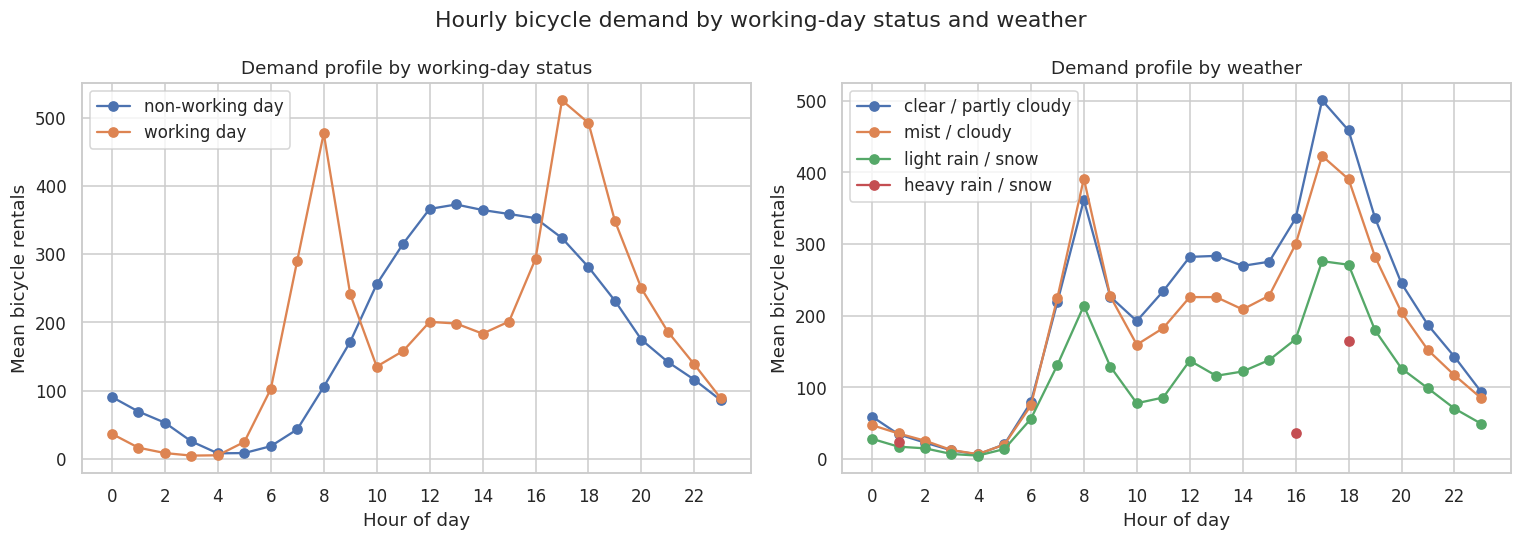

Task 11 passed.


In [ ]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

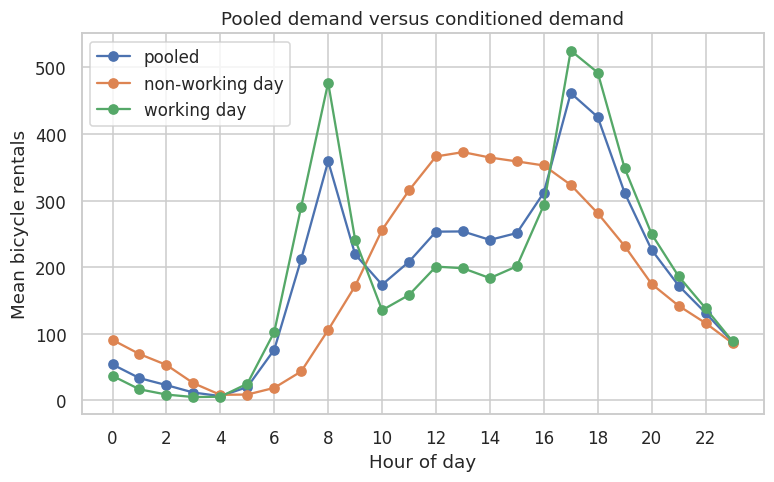

Selected hourly means:
hour 08: pooled=359.01, non-working=105.65, working=477.01
hour 13: pooled=253.66, non-working=372.73, working=198.43
hour 17: pooled=461.45, non-working=323.55, working=525.29
hour 18: pooled=425.51, non-working=281.06, working=492.23


In [ ]:
# Pooled hourly demand: ignore workingday completely.
pooled_profile = (
    bikes.groupby("hr")["cnt"]
    .mean()
)

# Conditioned profiles, for comparison.
conditioned_profile = (
    bikes.groupby(["hr", "workingday"])["cnt"]
    .mean()
    .unstack("workingday")
)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    pooled_profile.index,
    pooled_profile.values,
    marker="o",
    label="pooled"
)

ax.plot(
    conditioned_profile.index,
    conditioned_profile[0],
    marker="o",
    label="non-working day"
)

ax.plot(
    conditioned_profile.index,
    conditioned_profile[1],
    marker="o",
    label="working day"
)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean bicycle rentals")
ax.set_title("Pooled demand versus conditioned demand")
ax.set_xticks(range(0, 24, 2))
ax.legend()

plt.show()


print("Selected hourly means:")
for hour in [8, 13, 17, 18]:
    print(
        f"hour {hour:02d}: "
        f"pooled={pooled_profile.loc[hour]:.2f}, "
        f"non-working={conditioned_profile.loc[hour, 0]:.2f}, "
        f"working={conditioned_profile.loc[hour, 1]:.2f}"
    )

**(a)** The pooled hourly profile averages working days and non-working days together, but the two underlying groups have very different shapes. On working days, bicycle demand has a strong morning commuter peak at 08:00 and another large peak around 17:00–18:00. On non-working days, demand rises more gradually and stays high through the middle of the day, producing a broad daytime or afternoon profile rather than two narrow commuting peaks.

The numerical results show how much the pooled curve hides. At 08:00, the pooled mean is `359.01` rentals, but the non-working-day mean is only `105.65` while the working-day mean is `477.01`. At 13:00, the pooled mean is `253.66`, compared with `372.73` on non-working days and only `198.43` on working days. At 17:00, the pooled value is `461.45`, while the two underlying means are `323.55` and `525.29`. Therefore, the pooled profile could support the misleading statement that there is one general daily demand pattern with moderate morning demand and a broad afternoon/evening peak, even though neither subgroup actually has that shape.

The pooled curve is therefore not a typical daily profile. It is a weighted average of two different behaviours: commuting behaviour on working days and a broader leisure-oriented daytime pattern on non-working days.

**(b)** This is an example of Simpson's paradox / aggregation bias: an aggregate relationship can differ substantially from the relationships observed after conditioning on an important grouping variable. Here, `workingday` is the conditioning variable, and averaging across it hides the fact that hourly demand follows two distinct patterns.

The general rule is that an aggregate should not be interpreted by itself when a relevant third variable changes the relationship being studied. Before reporting a pooled average, I should check whether important subgroups behave differently, and when they do, report the conditional results together with the aggregate rather than presenting the average as representative of everyone.

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

In [ ]:
# =========================================================
# Task 12 — Data-quality and structure report
# =========================================================

report = bikes.copy()

print("Original shape:", report.shape)
print("\nOriginal dtypes:")
print(report.dtypes)


# =========================================================
# 1. TYPES
# =========================================================

# These columns are stored as integers but represent categories / states,
# not ordinary continuous quantities.
category_cols = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
]

typed = report.copy()

for col in category_cols:
    typed[col] = typed[col].astype("category")

typed["dteday"] = pd.to_datetime(typed["dteday"])

print("\n1. TYPES AFTER FIX:")
print(typed.dtypes)

print("\nExample of an operation that is now rejected:")
try:
    print(typed["season"].mean())
except TypeError as exc:
    print("TypeError:", exc)


# =========================================================
# 2. RESTORE PHYSICAL UNITS
# =========================================================

units = report.copy()

units["temp_c"] = units["temp"] * 41
units["atemp_c"] = units["atemp"] * 50
units["humidity_percent"] = units["hum"] * 100
units["windspeed_kmh"] = units["windspeed"] * 67

print("\n2. RESTORED PHYSICAL UNITS:")

for col in [
    "temp_c",
    "atemp_c",
    "humidity_percent",
    "windspeed_kmh",
]:
    print(
        f"{col:20s} "
        f"min={units[col].min():8.2f} "
        f"max={units[col].max():8.2f}"
    )


# =========================================================
# 3. DATE / HOURLY COMPLETENESS
# =========================================================

dates = report.copy()

dates["dteday"] = pd.to_datetime(dates["dteday"])

dates["timestamp"] = (
    dates["dteday"]
    + pd.to_timedelta(dates["hr"], unit="h")
)

expected_hours = pd.date_range(
    start=dates["timestamp"].min(),
    end=dates["timestamp"].max(),
    freq="h",
)

actual_hours = pd.DatetimeIndex(dates["timestamp"])

missing_hours = expected_hours.difference(actual_hours)

print("\n3. DATE COMPLETENESS:")
print("First timestamp:", dates["timestamp"].min())
print("Last timestamp :", dates["timestamp"].max())
print("Observed rows  :", len(dates))
print("Expected hours :", len(expected_hours))
print("Missing hours  :", len(missing_hours))
print("Duplicate timestamps:", dates["timestamp"].duplicated().sum())

missing_table = pd.DataFrame({
    "timestamp": missing_hours
})

missing_table["hour"] = missing_table["timestamp"].dt.hour
missing_table["date"] = missing_table["timestamp"].dt.date
missing_table["month"] = missing_table["timestamp"].dt.to_period("M")

print("\nMissing hours by hour of day:")
print(
    missing_table["hour"]
    .value_counts()
    .sort_index()
)

print("\nMonths with the most missing hours:")
print(
    missing_table["month"]
    .value_counts()
    .head(12)
)

print("\nFirst 20 missing timestamps:")
print(missing_table["timestamp"].head(20).to_string(index=False))


# =========================================================
# 4. CORRELATIONS THAT CAN MISLEAD
# =========================================================

numeric = report.select_dtypes(include=np.number)

corr = numeric.corr()

print("\n4. SELECTED CORRELATIONS:")

selected_pairs = [
    ("season", "mnth"),
    ("hr", "cnt"),
    ("temp", "atemp"),
    ("casual", "cnt"),
    ("registered", "cnt"),
]

for a, b in selected_pairs:
    print(
        f"{a:12s} vs {b:12s}: "
        f"{corr.loc[a, b]:+.4f}"
    )

# strongest absolute correlations, excluding diagonal duplicates
pairs = []

columns = corr.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        pairs.append({
            "a": columns[i],
            "b": columns[j],
            "correlation": corr.iloc[i, j],
            "abs_correlation": abs(corr.iloc[i, j]),
        })

strongest = (
    pd.DataFrame(pairs)
    .sort_values("abs_correlation", ascending=False)
    .head(15)
)

print("\nStrongest numeric correlations:")
print(
    strongest[
        ["a", "b", "correlation"]
    ].to_string(index=False)
)


# =========================================================
# 5. LEAKAGE
# =========================================================

identity = (
    report["casual"]
    + report["registered"]
    == report["cnt"]
)

print("\n5. LEAKAGE CHECK:")
print(
    "casual + registered == cnt for every row:",
    bool(identity.all())
)

print(
    "Rows where identity fails:",
    int((~identity).sum())
)


# =========================================================
# 6. BASIC MODEL-HANDOVER SUMMARY
# =========================================================

print("\n6. CANDIDATE MODEL COLUMNS:")

candidate_features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
    "temp",
    "atemp",
    "hum",
    "windspeed",
]

excluded = [
    "instant",
    "dteday",
    "casual",
    "registered",
    "cnt",
]

print("Candidate features:")
print(candidate_features)

print("\nExclude from X:")
print(excluded)

print("\nTarget:")
print("cnt")

Original shape: (17379, 17)

Original dtypes:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

1. TYPES AFTER FIX:
instant                int64
dteday        datetime64[ns]
season              category
yr                  category
mnth                category
hr                  category
holiday             category
weekday             category
workingday          category
weathersit          category
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object

Example of an operation that is now r

### Task 12 — Data-quality and structure report

**1. Types**

Several columns are stored as integers even though the numbers represent categories rather than ordinary quantitative measurements. In particular, `season`, `mnth`, `weekday` and `weathersit` should not be interpreted as continuous numerical quantities. For example, calculating the arithmetic mean of `season` is syntactically possible when the column is stored as an integer, but the result has no meaningful interpretation because season 4 is not “twice” season 2.

I converted the categorical columns to pandas `category` dtype and parsed `dteday` as a datetime. After converting `season` to a categorical variable, an operation such as `season.mean()` raises a `TypeError` instead of silently returning a meaningless number. This is an example where the original inferred dtype was not technically invalid, but it permitted semantically wrong operations.

`hr` also needs special treatment in modelling. Although it is stored as 0–23, the relationship between hour and bicycle demand is strongly non-linear and cyclic: 23:00 is adjacent to 00:00, which an ordinary numeric scale does not represent.

**2. Units**

The four weather variables were distributed in normalised form. I restored them using the documented scale factors:

- `temp × 41` → temperature in °C;
- `atemp × 50` → apparent temperature in °C;
- `hum × 100` → relative humidity in %;
- `windspeed × 67` → wind speed in km/h.

The restored ranges are approximately `0.82–41.00 °C` for temperature, `0–50 °C` for apparent temperature, `0–100%` for humidity, and `0–57 km/h` for wind speed. The temperature and wind-speed ranges are plausible for Washington, D.C. over two years. The value of `0%` relative humidity is unusual enough to deserve inspection, but the range alone is not sufficient evidence that the row is erroneous. Restoring the units therefore changes interpretation and enables sanity checks, but I would not delete observations solely from these extrema.

**3. Date completeness**

After parsing `dteday` and combining it with `hr`, the data span 2011–2012. A complete two-year hourly sequence would contain `17,544` hourly timestamps, while the table contains `17,379` rows, so `165` hourly observations are missing. I found no duplicate timestamps.

The missing timestamps do not look random. The first missing observations are concentrated in overnight and very early morning hours, for example 02:00, 03:00, 04:00 and 05:00 on several January dates. This pattern suggests that absence is related to time of day, rather than being uniformly distributed over the series. That matters for modelling because simply treating the observed rows as a complete regular hourly series could bias estimates of low-demand overnight periods.

**4. Correlations that should not be interpreted mechanically**

The numeric correlation matrix contains mathematically valid coefficients that are nevertheless misleading.

One example is `season` versus `mnth`, with a correlation of approximately `+0.8304`. This is largely an artefact of integer coding and the calendar structure. `season` is a category and month is cyclic, so a Pearson correlation between their integer codes should not be interpreted as a meaningful linear physical relationship.

A second example is `hr` versus `cnt`, with a Pearson correlation of approximately `+0.3941`. The coefficient is not wrong mathematically, but it is a poor summary of the actual relationship because hourly demand is strongly non-linear, with commuting peaks around 08:00 and 17:00–18:00. A single linear coefficient hides this structure.

By contrast, the very high correlation between `temp` and `atemp`, approximately `+0.9877`, is interpretable because both are continuous temperature-related measurements.

The correlations of `casual` with `cnt` (`+0.6946`) and especially `registered` with `cnt` (`+0.9722`) are also misleading for prediction because these are not independent explanatory measurements: they are components of the target itself.

**5. Leakage**

The identity

`casual + registered == cnt`

is true for every row in the dataset; I found `0` rows where it fails. Therefore, `casual` and `registered` must not be used as predictors when the task is to predict total demand `cnt`. Giving either of these variables to the model would reveal part of the answer, and giving both reveals the target exactly. Any resulting accuracy would therefore measure target leakage rather than genuine predictive performance.

A realistic task in which these columns would be legitimate is a different target. For example, if `cnt` is already known after an hour has finished and the goal is to predict the proportion of rentals made by registered users, or to analyse the composition of demand rather than forecast total demand in advance, then `casual` and `registered` can be valid variables. Their legitimacy depends on what information would actually be available at prediction time.

**6. Recommendation for modelling hourly demand**

For a model that predicts future hourly bicycle demand, I would use calendar and weather information that would plausibly be available before the hour being predicted: `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`, `temp`, `atemp`, `hum` and `windspeed`. Categorical and cyclic fields should be encoded appropriately rather than treated automatically as ordinary continuous numbers. I would exclude `instant` because it is only a record identifier, exclude `casual` and `registered` because they leak the target, and use `cnt` only as the response variable. I would not pass raw `dteday` directly as an arbitrary numeric value; instead, I would derive useful temporal features from it if needed. The most important findings for the modelling decision are the target leakage, the categorical/cyclic nature of several integer columns, and the non-random missing hourly timestamps. The normalised weather units are not themselves a modelling error, but restoring them is essential for interpretation and data-quality checks.

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.